In [27]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [28]:
years = 15

endDate = dt.datetime.now()
startDate = endDate - dt .timedelta(days = 365*years)

In [29]:
tickers = ['SPY','BND', 'QQQ', 'VTI','GLD']

In [30]:
data = yf.download(tickers, start=startDate, end=endDate, auto_adjust=False)['Adj Close']
adj_close_df = data.dropna()
print(adj_close_df)

[*********************100%***********************]  5 of 5 completed

Ticker            BND         GLD         QQQ         SPY         VTI
Date                                                                 
2011-09-30  54.278366  158.059998   46.137352   87.137840   44.720634
2011-10-03  54.586430  160.960007   44.950733   84.658073   43.240791
2011-10-04  54.372013  157.639999   45.873631   86.514069   44.325497
2011-10-05  54.138042  159.460007   47.051491   88.115891   45.231991
2011-10-06  54.105549  160.490005   47.842537   89.710014   46.107491
...               ...         ...         ...         ...         ...
2026-09-21  71.400002  398.380005  741.469971  773.500000  381.100006
2026-09-22  71.410004  400.070007  747.460022  773.380005  381.269989
2026-09-23  70.809998  392.880005  741.210022  767.809998  378.230011
2026-09-24  70.449997  391.690002  741.099976  767.179993  378.079987
2026-09-25  70.629997  393.410004  744.500000  771.349976  379.769989

[3768 rows x 5 columns]


In [31]:
log_returns = np.log(adj_close_df/adj_close_df.shift(1))
log_returns = log_returns.dropna()

print(log_returns)

Ticker           BND       GLD       QQQ       SPY       VTI
Date                                                        
2011-10-03  0.005660  0.018181 -0.026056 -0.028871 -0.033651
2011-10-04 -0.003936 -0.020842  0.020323  0.021687  0.024776
2011-10-05 -0.004312  0.011479  0.025352  0.018346  0.020245
2011-10-06 -0.000600  0.006439  0.016673  0.017930  0.019171
2011-10-07 -0.002164 -0.008196 -0.006636 -0.006718 -0.009115
...              ...       ...       ...       ...       ...
2026-09-21  0.002805 -0.006979  0.028413  0.015386  0.014990
2026-09-22  0.000140  0.004233  0.008046 -0.000155  0.000446
2026-09-23 -0.008438 -0.018135 -0.008397 -0.007228 -0.008005
2026-09-24 -0.005097 -0.003034 -0.000148 -0.000821 -0.000397
2026-09-25  0.002552  0.004382  0.004577  0.005421  0.004460

[3767 rows x 5 columns]


In [32]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)

[0.2 0.2 0.2 0.2 0.2]


In [33]:
historical_returns = (log_returns * weights).sum(axis =1)
print(historical_returns)

Date
2011-10-03   -0.012947
2011-10-04    0.008402
2011-10-05    0.014222
2011-10-06    0.011922
2011-10-07   -0.006566
                ...   
2026-09-21    0.010923
2026-09-22    0.002542
2026-09-23   -0.010041
2026-09-24   -0.001899
2026-09-25    0.004278
Length: 3767, dtype: float64


In [34]:
days = 5
range_returns = historical_returns.rolling(window=days).sum()
range_returns = range_returns.dropna()
print(range_returns)

Date
2011-10-07    0.015033
2011-10-10    0.052913
2011-10-11    0.044695
2011-10-12    0.036481
2011-10-13    0.024792
                ...   
2026-09-21    0.019743
2026-09-22    0.024893
2026-09-23    0.017873
2026-09-24    0.003739
2026-09-25    0.005803
Length: 3763, dtype: float64


 **Historical Method**

In [35]:
confidence_interval = 0.95

VaR = -np.percentile(range_returns, 100 - (confidence_interval*100))*portfolio_value
print(VaR)

23432.785191581916


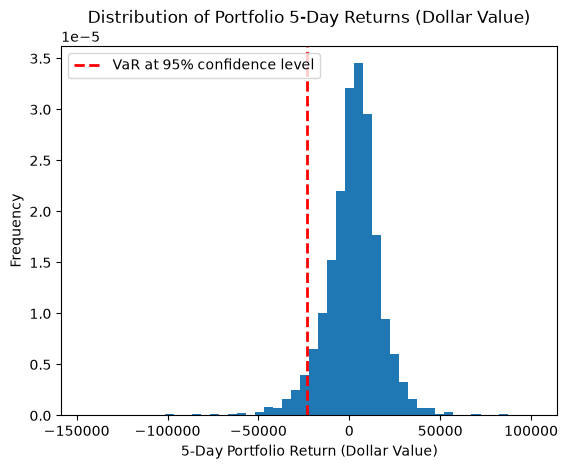

In [36]:
return_window = days
range_returns = historical_returns.rolling(window=return_window).sum()
range_returns = range_returns.dropna()

range_returns_dollar = range_returns * portfolio_value

plt.hist(range_returns_dollar.dropna(), bins=50, density=True)
plt.xlabel(f'{return_window}-Day Portfolio Return (Dollar Value)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {return_window}-Day Returns (Dollar Value)')
plt.axvline(-VaR, color='r', linestyle='dashed', linewidth=2, label=f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()


**Parametric Method**

In [37]:
cov_matrix = log_returns.cov()* 252 

In [38]:
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [39]:
from scipy.stats import norm

confidence_levels = [0.90, 0.95, 0.99]

VaRs = []
for cl in confidence_levels:
    VaR = -portfolio_value * (norm.ppf(1 - cl) * portfolio_std_dev * np.sqrt(days / 252) - historical_returns.mean() * days)
    VaRs.append(VaR)

In [40]:
print(f'{"Confidence Level":<20} {"Value at Risk":<20}')
print('-' * 40)

for cl, VaR in zip(confidence_levels, VaRs):
    print(f'{cl * 100:>6.0f}%: {"":<8} ${VaR:>10,.2f}')

Confidence Level     Value at Risk       
----------------------------------------
    90%:          $ 23,325.17
    95%:          $ 29,314.71
    99%:          $ 40,550.10


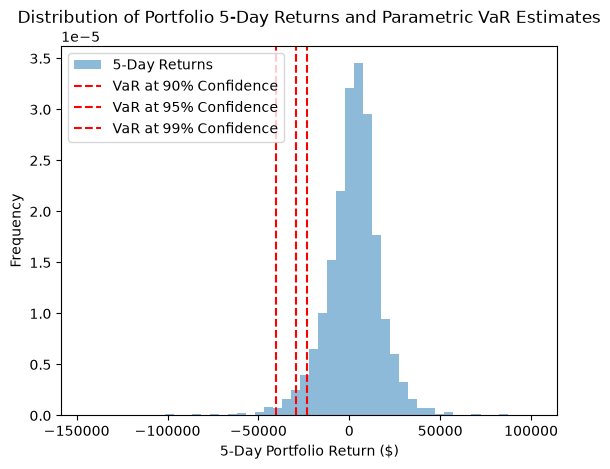

In [41]:
range_returns_dollar = range_returns * portfolio_value

plt.hist(range_returns_dollar, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')

for cl, VaR in zip(confidence_levels, VaRs):
    plt.axvline(x=-VaR, linestyle='--', color='r', label=f'VaR at {int(cl*100)}% Confidence')

plt.xlabel(f'{days}-Day Portfolio Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
plt.legend()
plt.show()

**Monte Carlo Method**


In [42]:
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean()*weights)

In [43]:
def standard_deviation (weights , cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [44]:
cov_matrix = log_returns.cov()
print(cov_matrix)


Ticker       BND       GLD       QQQ       SPY       VTI
Ticker                                                  
BND     0.000010  0.000009  0.000003  0.000002  0.000003
GLD     0.000009  0.000110  0.000013  0.000010  0.000010
QQQ     0.000003  0.000013  0.000169  0.000128  0.000130
SPY     0.000002  0.000010  0.000128  0.000111  0.000113
VTI     0.000003  0.000010  0.000130  0.000113  0.000116


In [45]:
portfolio_value = 1000000   
weights = np.array([1/len(tickers)]*len(tickers))
portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std_dev = standard_deviation(weights, cov_matrix)

In [46]:
def random_z_score():
    return np.random.normal(0,1)

In [47]:
days = 5
def scenario_gain_loss(portfolio_value, portfolio_std_dev , z_score, days):
    return portfolio_value * portfolio_expected_return * days + portfolio_value * portfolio_std_dev * z_score * np.sqrt(days)


In [48]:
simulations = 10000
scenarioReturn = []

for i in range(simulations):
    z_score = random_z_score()
    scenarioReturn.append(scenario_gain_loss(portfolio_value, portfolio_std_dev , z_score, days))
    

In [49]:
confidence_interval = 0.95
VaR = -np.percentile(scenarioReturn, 100*(1-confidence_interval))
print(VaR)

25250.8032925245


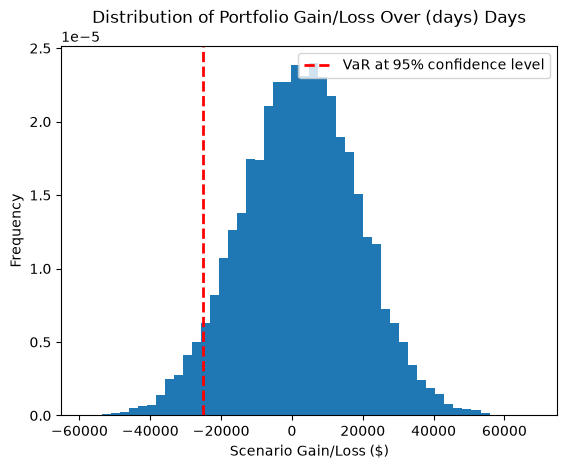

In [50]:
plt.hist(scenarioReturn, bins=50, density=True)
plt.xlabel('Scenario Gain/Loss ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio Gain/Loss Over (days) Days')
plt.axvline(-VaR, color='r', linestyle='dashed', linewidth=2, label=f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()

**Backtesting The VaR**

In [51]:
confidence_interval = 0.95
window = 500
simulations = 10000

historical_breaches = 0
parametric_breaches = 0
monte_carlo_breaches = 0
total_tests = 0

for i in range(window, len(historical_returns) - days):

    past_returns = historical_returns.iloc[i-window:i]

    past_5day_returns = past_returns.rolling(days).sum().dropna()

    historical_VaR = -np.percentile(
        past_5day_returns,
        100 * (1 - confidence_interval)
    ) * portfolio_value

    mean_return = past_returns.mean()
    std_return = past_returns.std()

    parametric_VaR = -portfolio_value * (
        norm.ppf(1 - confidence_interval)
        * std_return
        * np.sqrt(days)
        - mean_return * days
    )

    simulated_returns = (
        mean_return * days
        + std_return * np.sqrt(days)
        * np.random.normal(0, 1, simulations)
    )

    monte_carlo_VaR = -np.percentile(
        simulated_returns,
        100 * (1 - confidence_interval)
    ) * portfolio_value

    actual_return = historical_returns.iloc[i:i+days].sum()
    actual_loss = -actual_return * portfolio_value

    if actual_loss > historical_VaR:
        historical_breaches += 1

    if actual_loss > parametric_VaR:
        parametric_breaches += 1

    if actual_loss > monte_carlo_VaR:
        monte_carlo_breaches += 1

    total_tests += 1

print("VaR Backtesting Results")
print("-----------------------")
print("Expected Breach Rate:", (1-confidence_interval)*100, "%")
print("Historical VaR Breach Rate:", historical_breaches/total_tests*100, "%")
print("Parametric VaR Breach Rate:", parametric_breaches/total_tests*100, "%")
print("Monte Carlo VaR Breach Rate:", monte_carlo_breaches/total_tests*100, "%")

VaR Backtesting Results
-----------------------
Expected Breach Rate: 5.000000000000004 %
Historical VaR Breach Rate: 6.039239730226854 %
Parametric VaR Breach Rate: 3.310852237890864 %
Monte Carlo VaR Breach Rate: 5.242182709993869 %


**Interpretation:** The Parametric VaR breach rate (3.3%) is meaningfully below the 
expected 5%, meaning it is *overestimating* risk (too conservative) on average. 

**Conclusion**
This project evaluates portfolio risk using Historical, Parametric, and Monte Carlo VaR over a 5-day holding period. VaR backtesting is also performed to assess model performance against actual portfolio losses. The project demonstrates practical application of market risk measurement, portfolio analysis, and Python-based risk modelling.